# 03.5 - Correlation & Regression Basics

**Phase:** 03 - Statistics & Probability

**Status:** VERIFIED

---

## 1. What Are We Solving?

**Correlation** measures the strength and direction of a linear relationship between two variables. **Regression** models that relationship so we can make predictions. These are foundational for ML: almost every predictive model is a form of regression.

## 2. Why Does This Matter?

Before building any ML model, you need to understand how features relate to each other and to the target. Correlation helps you find useful features and detect multicollinearity. Regression is the simplest predictive model and the building block for everything else.

## 3. Prerequisites

- Unit 03.1 (Descriptive statistics)
- Unit 02.1 (Vectors & matrices)

## 4. Learning Objectives

By the end of this notebook, you should be able to:
- Compute and interpret Pearson correlation
- Understand covariance and its limitations
- Fit a simple linear regression model
- Interpret slope, intercept, and R-squared
- Understand that correlation is not causation

## 5. Mental Model

**Correlation** (r) ranges from -1 to +1: +1 is a perfect positive linear relationship, -1 perfect negative, 0 no linear relationship. **Regression** finds the line `y = mx + b` that best fits the data by minimizing the sum of squared errors.

Key: correlation measures association, not causation.


## 6. Covariance and Correlation

**Covariance** measures how two variables vary together, but its scale depends on the units. **Pearson correlation** normalizes covariance by the standard deviations, giving a unitless value in [-1, 1].

`r = cov(x, y) / (std(x) * std(y))`


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

# Generate data with a known positive correlation
x = np.random.normal(0, 1, 200)
y = 2 * x + np.random.normal(0, 1, 200)  # y depends on x plus noise

# Compute correlation
r = np.corrcoef(x, y)[0, 1]
r_scipy, p_value = stats.pearsonr(x, y)

print(f"Pearson correlation (numpy): {r:.3f}")
print(f"Pearson correlation (scipy): {r_scipy:.3f}")
print(f"p-value: {p_value:.2e}")
print("\nStrong positive correlation: as x increases, y tends to increase.")


Pearson correlation (numpy): 0.894
Pearson correlation (scipy): 0.894
p-value: 8.39e-71

Strong positive correlation: as x increases, y tends to increase.


## 7. Visualizing Correlation

A scatter plot shows the relationship. Let's look at positive, negative, and zero correlation.


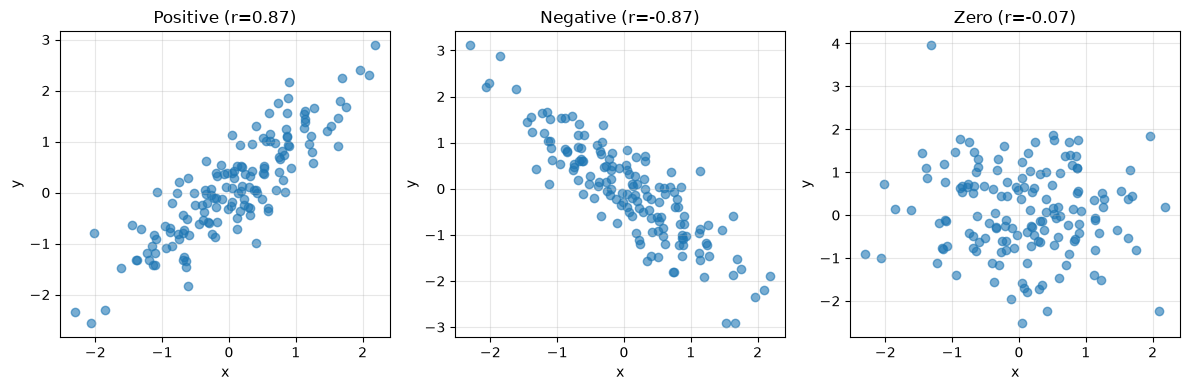

Correlation captures linear relationships. Zero correlation does not mean no relationship at all.


In [2]:
# Scatter plots for different correlations
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

np.random.seed(1)
x = np.random.normal(0, 1, 150)

# Positive correlation
y_pos = x + np.random.normal(0, 0.5, 150)
axes[0].scatter(x, y_pos, alpha=0.6)
axes[0].set_title(f"Positive (r={np.corrcoef(x, y_pos)[0,1]:.2f})")

# Negative correlation
y_neg = -x + np.random.normal(0, 0.5, 150)
axes[1].scatter(x, y_neg, alpha=0.6)
axes[1].set_title(f"Negative (r={np.corrcoef(x, y_neg)[0,1]:.2f})")

# Zero correlation
y_zero = np.random.normal(0, 1, 150)
axes[2].scatter(x, y_zero, alpha=0.6)
axes[2].set_title(f"Zero (r={np.corrcoef(x, y_zero)[0,1]:.2f})")

for ax in axes:
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("Correlation captures linear relationships. Zero correlation does not mean no relationship at all.")


## 8. Correlation is Not Causation

Two variables can be correlated without one causing the other. A classic example: ice cream sales and drowning deaths both rise in summer, but ice cream doesn't cause drowning - both are driven by a third factor (warm weather).

Correlation can also be **spurious** (pure coincidence). Always think about confounding variables.


In [3]:
# Demonstrating a spurious correlation
np.random.seed(3)
n = 100
# Two unrelated variables that happen to trend together over time
time = np.arange(n)
ice_cream = 10 + 0.1 * time + np.random.normal(0, 1, n)
drownings = 5 + 0.08 * time + np.random.normal(0, 1, n)

r = np.corrcoef(ice_cream, drownings)[0, 1]
print(f"Correlation between ice cream sales and drownings: {r:.3f}")
print("Both rise over time (summer), but neither causes the other.")
print("This is a spurious correlation driven by a hidden factor.")


Correlation between ice cream sales and drownings: 0.845
Both rise over time (summer), but neither causes the other.
This is a spurious correlation driven by a hidden factor.


## 9. Simple Linear Regression

**Simple linear regression** fits a line `y = mx + b` to predict y from x. We choose m and b to minimize the **sum of squared errors** (SSE).

The slope `m` tells us: for a one-unit increase in x, y changes by m on average.


In [4]:
# Fit a simple linear regression by hand (least squares)
np.random.seed(5)
x = np.random.normal(0, 1, 200)
y = 3 * x + 2 + np.random.normal(0, 1, 200)

# Least squares formulas
m = np.cov(x, y, ddof=1)[0, 1] / np.var(x, ddof=1)
b = np.mean(y) - m * np.mean(x)

# Predictions
y_pred = m * x + b

# R-squared: fraction of variance explained
ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r2 = 1 - ss_res / ss_tot

print(f"Slope (m): {m:.3f} (true: 3)")
print(f"Intercept (b): {b:.3f} (true: 2)")
print(f"R-squared: {r2:.3f}")
print("\nR-squared = 0.90 means the model explains 90% of the variance in y.")


Slope (m): 2.997 (true: 3)
Intercept (b): 2.012 (true: 2)
R-squared: 0.899

R-squared = 0.90 means the model explains 90% of the variance in y.


## 10. Visualizing the Regression Line


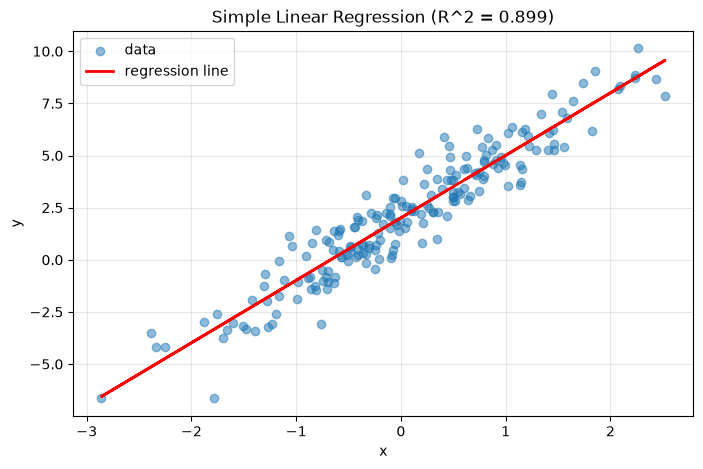

In [5]:
# Plot data and regression line
plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.5, label="data")
plt.plot(x, y_pred, color="red", linewidth=2, label="regression line")
plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Simple Linear Regression (R^2 = {r2:.3f})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 11. Using scipy for Regression

scipy's `linregress` gives slope, intercept, R-squared, and a p-value for the slope.


In [6]:
# Use scipy.stats.linregress
result = stats.linregress(x, y)
print(f"Slope: {result.slope:.3f}")
print(f"Intercept: {result.intercept:.3f}")
print(f"R-squared: {result.rvalue**2:.3f}")
print(f"p-value (slope != 0): {result.pvalue:.2e}")
print(f"Standard error of slope: {result.stderr:.3f}")
print("\nThe tiny p-value confirms the slope is significantly different from 0.")


Slope: 2.997
Intercept: 2.012
R-squared: 0.899
p-value (slope != 0): 1.41e-100
Standard error of slope: 0.071

The tiny p-value confirms the slope is significantly different from 0.


## 12. Failure Case: Outliers

A single outlier can dramatically change both correlation and regression. Always visualize your data before trusting summary statistics.


In [7]:
# One outlier can change everything
np.random.seed(7)
x = np.random.normal(0, 1, 50)
y = x + np.random.normal(0, 0.3, 50)

r_clean = np.corrcoef(x, y)[0, 1]

# Add one extreme outlier
x_out = np.append(x, 10)
y_out = np.append(y, -10)
r_out = np.corrcoef(x_out, y_out)[0, 1]

print(f"Correlation without outlier: {r_clean:.3f}")
print(f"Correlation with one outlier: {r_out:.3f}")
print("\nA single outlier can flip the sign of the correlation!")


Correlation without outlier: 0.977
Correlation with one outlier: -0.203

A single outlier can flip the sign of the correlation!


## 13. Debugging: Common Errors

- **Correlation vs causation**: never claim causation from correlation.
- **Outliers**: always plot the data; one outlier can mislead.
- **Non-linear relationships**: r=0 doesn't mean no relationship (e.g. a U-shape).
- **Extrapolation**: don't predict far outside the observed x range.
- **Multicollinearity**: highly correlated features can destabilize models.

## 14. Real-World Considerations

- **Feature selection**: drop highly correlated redundant features.
- **EDA**: correlation matrices reveal relationships before modeling.
- **Regression** is the foundation of linear models, logistic regression, and neural nets.
- **R-squared** is not the whole story - check residuals too.

## 15. Common Mistakes

- Reporting correlation without a scatter plot.
- Using R-squared alone to judge a model.
- Extrapolating beyond the data range.
- Assuming linearity without checking.

## 16. When NOT to Use

- Don't use Pearson correlation for non-linear relationships - use Spearman.
- Don't use simple regression when multiple features matter - use multiple regression.
- Don't interpret correlation as causation.

## 17. Challenge

Given study hours and exam scores, fit a regression line and predict the score for a student who studies 8 hours.


In [8]:
# Challenge: predict exam score from study hours
np.random.seed(9)
hours = np.random.uniform(1, 10, 100)
scores = 5 * hours + 40 + np.random.normal(0, 5, 100)

result = stats.linregress(hours, scores)
predicted = result.slope * 8 + result.intercept

print(f"Slope: {result.slope:.2f} (points per study hour)")
print(f"Intercept: {result.intercept:.2f}")
print(f"R-squared: {result.rvalue**2:.3f}")
print(f"Predicted score for 8 hours: {predicted:.1f}")
print(f"Correlation between hours and scores: {result.rvalue:.3f}")


Slope: 4.97 (points per study hour)
Intercept: 40.76
R-squared: 0.870
Predicted score for 8 hours: 80.5
Correlation between hours and scores: 0.933


## 18. Closed-Book Recall

Without looking back:

1. What does a Pearson correlation of -0.8 mean?
2. How is correlation different from regression?
3. What does R-squared measure?
4. Why is correlation not causation?
5. How can an outlier affect correlation?

## 19. Teach-Back Questions

Explain to another person:

- Why do we normalize covariance to get correlation?
- What does the slope of a regression line tell you?
- Why should you always plot data before computing correlation?

## 20. Summary

You now understand correlation (strength and direction of linear relationships) and simple linear regression (modeling and predicting). You know that correlation is not causation, outliers can mislead, and R-squared measures explained variance.

## 21. Further Experiment

- Compute Spearman rank correlation for non-linear data.
- Build a correlation matrix for multiple features.
- Fit multiple linear regression with two features.

## 22. Verification Status

```
STATUS: VERIFIED
EXECUTION: PASS
DEPENDENCIES: numpy, matplotlib, scipy
OUTPUTS: PASS
LAST VERIFIED: 2026-08-28
```
